In [2]:
import pandas as pd
df=df = pd.read_csv("../Data/climate_newfeatures.csv")

from sklearn.ensemble import IsolationForest

features = df[["T2M","RH2M","WS10M","PRECTOTCORR"]]

iso = IsolationForest(contamination=0.01)

df["ANOMALY"] = iso.fit_predict(features)

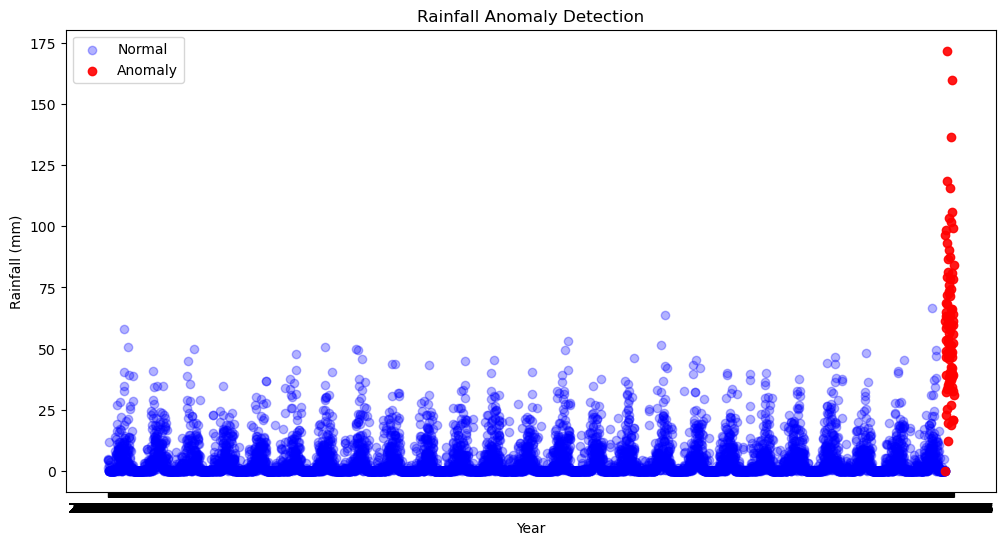

In [4]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,6))

normal = df[df["ANOMALY"] == 1]
anomaly = df[df["ANOMALY"] == -1]

plt.scatter(normal["DATE"], normal["PRECTOTCORR"], 
            color="blue", alpha=0.3, label="Normal")

plt.scatter(anomaly["DATE"], anomaly["PRECTOTCORR"], 
            color="red", alpha=0.9, label="Anomaly")

plt.title("Rainfall Anomaly Detection")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()

plt.show()

In [5]:
print(df["ANOMALY"].value_counts())

ANOMALY
 1    9009
-1      91
Name: count, dtype: int64
